In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# ケーススタディ: ML 前処理パイプライン

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tatsuki-washimi/gwexpy/blob/main/docs/web/en/user_guide/tutorials/case_ml_preprocessing.ipynb)

`MLPreprocessor` クラスは、重力波データを機械学習向けに前処理するための scikit-learn スタイルの transformer API を提供します。DeepClean v2 で使用されている前処理パイプラインを実装しており、以下の機能を含みます。

- **データ分割**: 整数秒アライメントによる時間順の訓練/検証分割
- **バンドパスフィルタリング**: 複数周波数帯域に対応した Butterworth フィルタ
- **標準化**: チャンネルごとの正規化（Z スコアまたはロバスト MAD ベース）

この前処理は、ディープラーニングに限らず、あらゆる機械学習モデル（DeepClean、Random Forest、XGBoost など）に適用できます。

- **関連 API**: [Preprocessing API](../../reference/api/preprocessing.rst), [Time Series API](../../reference/api/timeseries.rst)
- **関連理論**: [検証済みアルゴリズム](../validated_algorithms.md), [数値安定性](../numerical_stability.md)

In [2]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import warnings

with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    # Suppress warnings for cleaner documentation output


In [3]:
import sys
from pathlib import Path

# Ensure the root directory is in sys.path
root = Path.cwd()
while root.parent != root:
    if (root / "gwexpy").exists():
        if str(root) not in sys.path:
            sys.path.insert(0, str(root))
        break
    root = root.parent

import matplotlib.pyplot as plt
import numpy as np

from gwexpy.signal.preprocessing import MLPreprocessor
from gwexpy.timeseries import TimeSeries, TimeSeriesMatrix

## 基本的な使い方

補助（ウィットネス）チャンネルとターゲットの strain チャンネルを表すダミーデータを作成しましょう。

In [4]:
# Generate dummy data
np.random.seed(42)
sample_rate = 4096  # Hz
duration = 10  # seconds
n_samples = sample_rate * duration
n_channels = 3

# Witness channels (auxiliary sensors)
witnesses = TimeSeriesMatrix(
    np.random.randn(n_channels, n_samples) * 10 + 50,  # Different mean/std
    t0=0,
    dt=1 / sample_rate,
    unit="m/s^2",
    channel_names=["SEIS-X", "SEIS-Y", "SEIS-Z"],
)

# Target strain channel with 60Hz noise
t = np.arange(n_samples) / sample_rate
signal_60hz = 2 * np.sin(2 * np.pi * 60 * t)
strain = TimeSeries(
    signal_60hz + np.random.randn(n_samples) * 0.5,
    t0=0,
    dt=1 / sample_rate,
    unit="strain",
    name="H1:GDS-CALIB_STRAIN",
)

print(f"Witnesses shape: {witnesses.shape}")
print(f"Strain length: {len(strain)}")
print(f"Duration: {duration} seconds")

Witnesses shape: (3, 1, 40960)
Strain length: 40960
Duration: 10 seconds


### 前処理パイプライン

一般的なワークフローは以下のとおりです。
1. **split()**: データを訓練セットと検証セットに分割する
2. **fit()**: 訓練データから統計量とフィルタ係数を学習する
3. **transform()**: 訓練/検証データに前処理を適用する

**軸順序の注意:** このノートブックでは、ウィットネス入力 `X` は GWexpy の channel-first 順序 `(n_channels, 1, n_samples)` のまま扱います。後段の ML ライブラリでは batch-major テンソルを要求することがありますが、転置はデータセット化やモデル入力の境界でだけ行い、前処理中は元の軸順序を保ってください。


In [5]:
# Create preprocessor with 55-65 Hz bandpass filter
preprocessor = MLPreprocessor(
    sample_rate=sample_rate,
    freq_low=[55.0],
    freq_high=[65.0],
    valid_frac=0.2,  # 20% validation
    standardization_method="zscore",
)

# Split data
X_train, y_train, X_valid, y_valid = preprocessor.split(witnesses, strain)

print(f"Training samples: {len(y_train)} ({len(y_train)/sample_rate:.1f}s)")
print(f"Validation samples: {len(y_valid)} ({len(y_valid)/sample_rate:.1f}s)")

Training samples: 32768 (8.0s)
Validation samples: 8192 (2.0s)


In [6]:
# Fit on training data
preprocessor.fit(X_train, y_train)

# Transform both train and validation
X_train_proc, y_train_proc = preprocessor.transform(X_train, y_train)
X_valid_proc, y_valid_proc = preprocessor.transform(X_valid, y_valid)

print(f"Processed train X shape: {X_train_proc.shape}")
print(f"Processed train y length: {len(y_train_proc)}")
print(f"Output units: X={X_train_proc.units[0,0]}, y={y_train_proc.unit}")

Processed train X shape: (3, 1, 32768)
Processed train y length: 32768
Output units: X=, y=


## データ分割の可視化

分割は時間順（前半が訓練用、後半が検証用）で行われ、DeepClean v2 の動作に合わせて整数秒でアライメントされます。

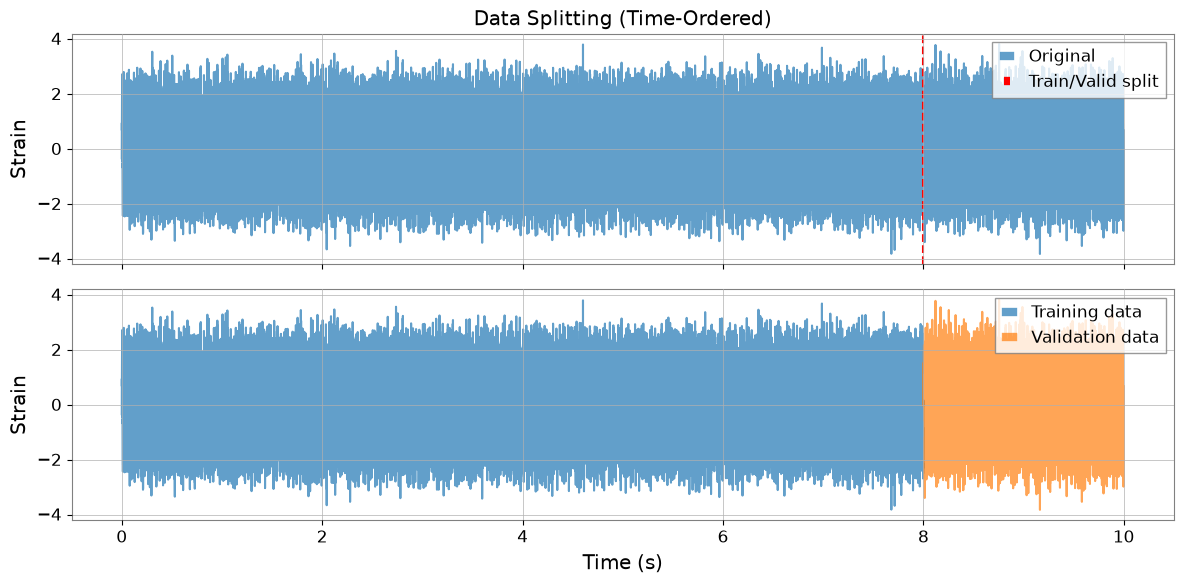

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Plot original strain
axes[0].plot(strain.times.value, strain.value, alpha=0.7, label="Original")
axes[0].axvline(
    y_train.t0.value + len(y_train) * y_train.dt.value,
    color="r",
    linestyle="--",
    label="Train/Valid split",
)
axes[0].set_ylabel("Strain")
axes[0].legend()
axes[0].set_title("Data Splitting (Time-Ordered)")

# Plot split data
axes[1].plot(
    y_train.times.value, y_train.value, label="Training data", alpha=0.7, color="C0"
)
axes[1].plot(
    y_valid.times.value, y_valid.value, label="Validation data", alpha=0.7, color="C1"
)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Strain")
axes[1].legend()

plt.tight_layout()
plt.show()

## フィルタリングと標準化の効果

**重要**:
- **ウィットネスチャンネル (X)** はフィルタリングされず、標準化のみが適用されます
- **ターゲットチャンネル (y)** はフィルタリング後に標準化されます

これは DeepClean v2 の処理順序に従っています。

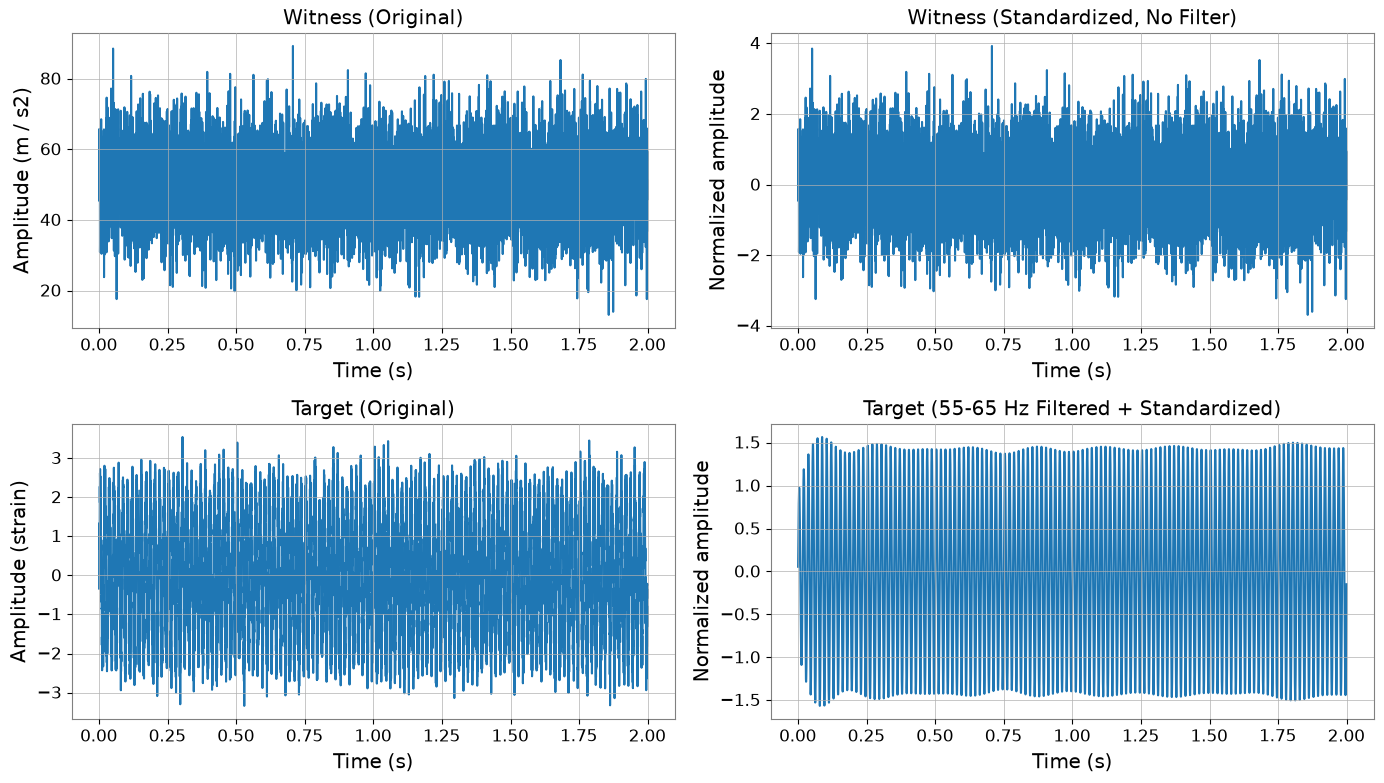

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Original witness channel (first 2 seconds)
time_mask = X_train.times.value < 2
axes[0, 0].plot(X_train.times.value[time_mask], X_train.value[0, 0, time_mask])
axes[0, 0].set_title("Witness (Original)")
axes[0, 0].set_ylabel(f"Amplitude ({X_train.units[0,0]})")
axes[0, 0].set_xlabel("Time (s)")

# Standardized witness (NO filtering)
axes[0, 1].plot(X_train_proc.times.value[time_mask], X_train_proc.value[0, 0, time_mask])
axes[0, 1].set_title("Witness (Standardized, No Filter)")
axes[0, 1].set_ylabel("Normalized amplitude")
axes[0, 1].set_xlabel("Time (s)")

# Original target
axes[1, 0].plot(y_train.times.value[time_mask[:len(y_train)]], y_train.value[time_mask[:len(y_train)]])
axes[1, 0].set_title("Target (Original)")
axes[1, 0].set_ylabel(f"Amplitude ({y_train.unit})")
axes[1, 0].set_xlabel("Time (s)")

# Filtered + standardized target
axes[1, 1].plot(y_train_proc.times.value[time_mask[:len(y_train_proc)]], y_train_proc.value[time_mask[:len(y_train_proc)]])
axes[1, 1].set_title("Target (55-65 Hz Filtered + Standardized)")
axes[1, 1].set_ylabel("Normalized amplitude")
axes[1, 1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

### 周波数領域解析

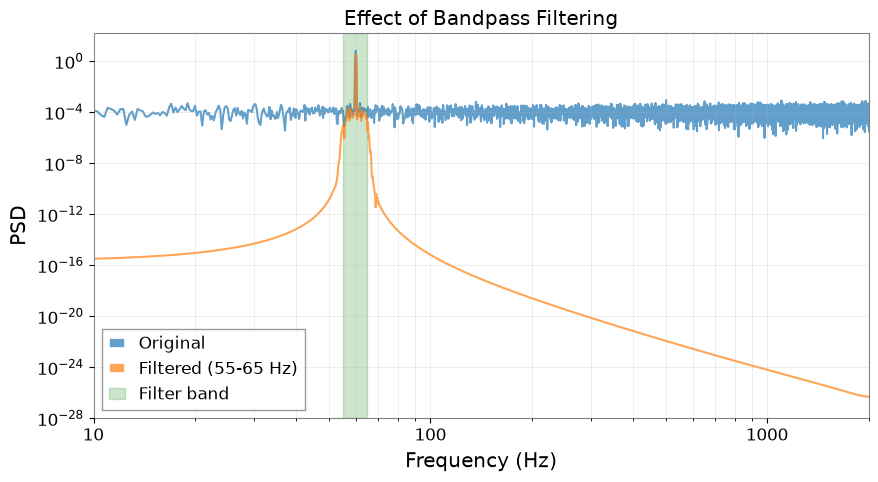

In [9]:
# Compute PSDs
fft_length = 4  # seconds
psd_original = y_train.psd(fftlength=fft_length)
psd_filtered = y_train_proc.psd(fftlength=fft_length)

plt.figure(figsize=(10, 5))
plt.loglog(psd_original.frequencies.value, psd_original.value, label="Original", alpha=0.7)
plt.loglog(psd_filtered.frequencies.value, psd_filtered.value, label="Filtered (55-65 Hz)", alpha=0.7)
plt.axvspan(55, 65, alpha=0.2, color="green", label="Filter band")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Effect of Bandpass Filtering")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.xlim(10, 2000)
plt.show()

## PyTorch 連携

前処理済みデータは、ディープラーニングモデル用に `TimeSeriesWindowDataset` と組み合わせて使用できます。

In [10]:
try:
    import torch  # noqa: F401

    from gwexpy.interop import TimeSeriesWindowDataset

    # Create dataset with 8-second windows, 0.0625-second stride
    train_dataset = TimeSeriesWindowDataset(
        X_train_proc,
        labels=y_train_proc,
        window=8 * sample_rate,
        stride=int(0.0625 * sample_rate),
    )

    print(f"Dataset size: {len(train_dataset)} windows")

    # Get a batch
    x_batch, y_batch = train_dataset[0]
    print(f"Batch shapes: X={x_batch.shape}, y={y_batch.shape}")
    print(f"X dtype: {x_batch.dtype}")
    print(f"y dtype: {y_batch.dtype}")

    # Create DataLoader
    from torch.utils.data import DataLoader
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    print(f"\nDataLoader created with {len(train_loader)} batches")

except ImportError:
    from IPython.display import Markdown, display
    display(Markdown("""**Note**: PyTorch is not installed.\n\nTo try this machine learning integration example:\n```bash\npip install torch\n```\n\nYou can continue with the rest of the notebook."""))


**Note**: PyTorch is not installed.

To try this machine learning integration example:
```bash
pip install torch
```

You can continue with the rest of the notebook.

## 発展的な話題

### 複数の周波数帯域

複数の周波数帯域を同時にフィルタリングできます（結果は合算されます）。

Number of filter bands: 2


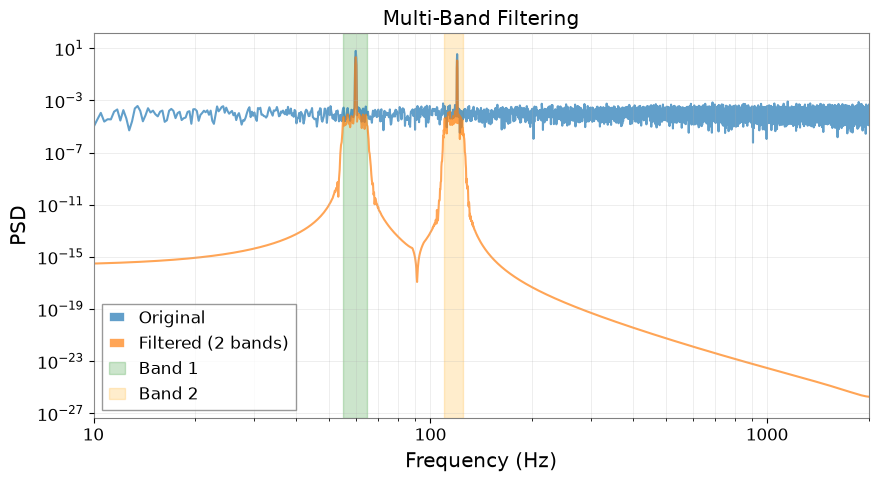

In [11]:
# Add 120 Hz noise to original data
signal_120hz = 1.5 * np.sin(2 * np.pi * 120 * t)
strain_multi = TimeSeries(
    signal_60hz + signal_120hz + np.random.randn(n_samples) * 0.5,
    t0=0,
    dt=1 / sample_rate,
    unit="strain",
)

# Preprocessor with two bands
preprocessor_multi = MLPreprocessor(
    sample_rate=sample_rate,
    freq_low=[55.0, 110.0],  # Two bands
    freq_high=[65.0, 125.0],
    valid_frac=0.2,
)

X_train_m, y_train_m, X_valid_m, y_valid_m = preprocessor_multi.split(
    witnesses, strain_multi
)
preprocessor_multi.fit(X_train_m, y_train_m)
_, y_train_multi_proc = preprocessor_multi.transform(X_train_m, y_train_m)

print(f"Number of filter bands: {len(preprocessor_multi.filter_coeffs_)}")

# Compare PSDs
psd_multi_orig = y_train_m.psd(fftlength=4)
psd_multi_filt = y_train_multi_proc.psd(fftlength=4)

plt.figure(figsize=(10, 5))
plt.loglog(psd_multi_orig.frequencies.value, psd_multi_orig.value, label="Original", alpha=0.7)
plt.loglog(psd_multi_filt.frequencies.value, psd_multi_filt.value, label="Filtered (2 bands)", alpha=0.7)
plt.axvspan(55, 65, alpha=0.2, color="green", label="Band 1")
plt.axvspan(110, 125, alpha=0.2, color="orange", label="Band 2")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Multi-Band Filtering")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.xlim(10, 2000)
plt.show()

### ロバスト標準化

外れ値を含むデータに対しては、Z スコアの代わりに `robust`（MAD ベース）標準化を使用します。

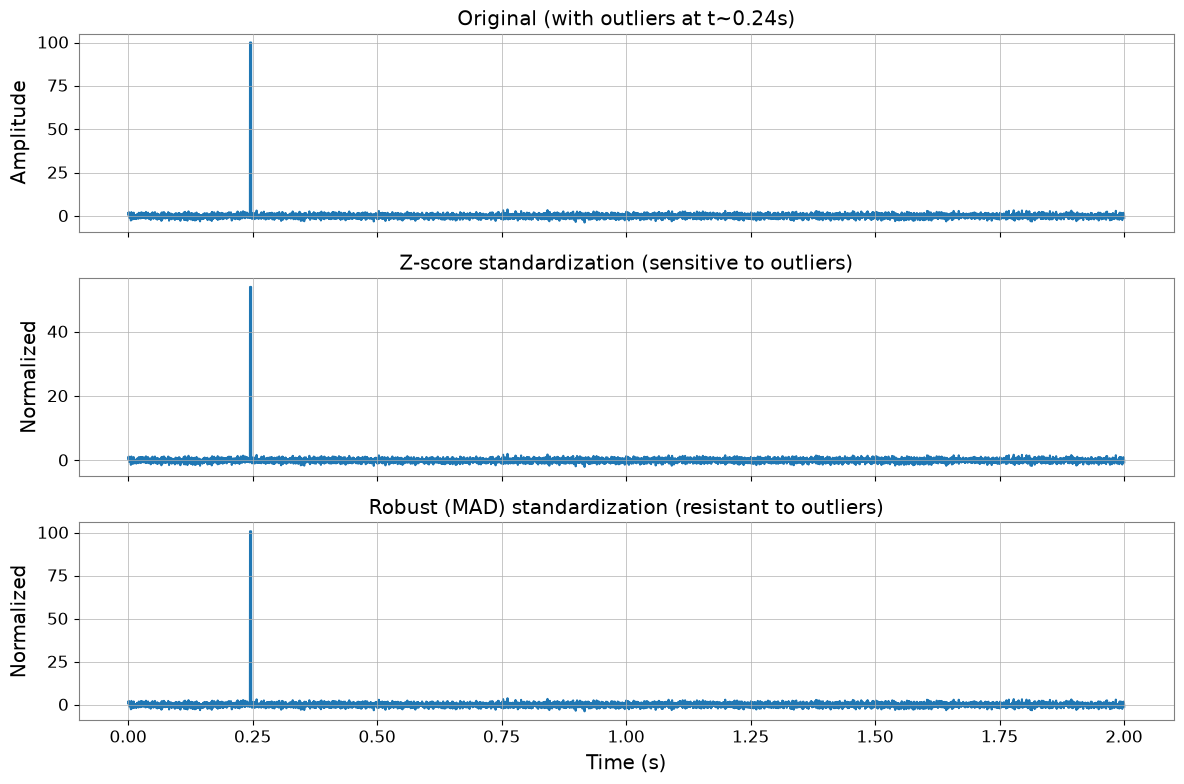

Z-score: mean=-0.000, std=1.000
Robust:  median=-0.000, MAD*1.4826=1.000


In [12]:
# Create data with outliers
np.random.seed(0)
data_with_outliers = np.random.randn(n_channels, n_samples)
data_with_outliers[0, 1000:1010] = 100  # Inject outliers
witnesses_outliers = TimeSeriesMatrix(
    data_with_outliers, t0=0, dt=1 / sample_rate, unit="m/s^2"
)

# Compare z-score vs robust
prep_zscore = MLPreprocessor(sample_rate=sample_rate, standardization_method="zscore")
prep_robust = MLPreprocessor(sample_rate=sample_rate, standardization_method="robust")

prep_zscore.fit(witnesses_outliers, y=None)
prep_robust.fit(witnesses_outliers, y=None)

X_zscore = prep_zscore.transform(witnesses_outliers, y=None)
X_robust = prep_robust.transform(witnesses_outliers, y=None)

# Plot comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

time_window = slice(0, 2 * sample_rate)  # First 2 seconds
times = witnesses_outliers.times.value[time_window]

axes[0].plot(times, witnesses_outliers.value[0, 0, time_window])
axes[0].set_title("Original (with outliers at t~0.24s)")
axes[0].set_ylabel("Amplitude")

axes[1].plot(times, X_zscore.value[0, 0, time_window])
axes[1].set_title("Z-score standardization (sensitive to outliers)")
axes[1].set_ylabel("Normalized")

axes[2].plot(times, X_robust.value[0, 0, time_window])
axes[2].set_title("Robust (MAD) standardization (resistant to outliers)")
axes[2].set_ylabel("Normalized")
axes[2].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

print(f"Z-score: mean={np.mean(X_zscore.value[0]):.3f}, std={np.std(X_zscore.value[0]):.3f}")
print(f"Robust:  median={np.median(X_robust.value[0]):.3f}, MAD*1.4826={np.median(np.abs(X_robust.value[0] - np.median(X_robust.value[0]))) * 1.4826:.3f}")

## まとめ

`MLPreprocessor` は以下の機能を提供します。

1. **柔軟な前処理**: あらゆる ML モデルに対応（DeepClean に限定されない）
2. **DeepClean v2 互換**: 同一の処理順序を再現
3. **容易な統合**: PyTorch、scikit-learn、XGBoost などとの連携が容易
4. **ロバストな処理**: エッジケース（単一チャンネル、外れ値、ゼロ分散）への対応

**処理順序のポイント**:
- ウィットネスチャンネル (X): 標準化のみ（フィルタリングなし）
- ターゲットチャンネル (y): フィルタリング → 標準化

詳細は [API ドキュメント](../../reference/api/preprocessing.rst) を参照してください。

- **関連 API**: [Preprocessing API](../../reference/api/preprocessing.rst), [Time Series API](../../reference/api/timeseries.rst)
- **関連理論**: [検証済みアルゴリズム](../validated_algorithms.md), [数値安定性](../numerical_stability.md)